Zelle 1: Setup und Laden der Daten über alle Probanden
Wir müssen eine Schleife bauen, die über alle Probanden geht, die Epochen lädt und die ERPs (Evokeds) berechnet. Um später die Statistik rechnen zu können, sammeln wir die Daten in Listen.

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Definiere deinen Datenordner und alle Probanden-IDs, die du hast
data_dir = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
subjects = ['17', '23', '26'] # Erweitere diese Liste später: ['14', '15', '16', ...]

# Listen zum Speichern der Differenzwellen pro Proband (für die Statistik)
diff_H4_list = [] # SI - SC
diff_H5_list = [] # PI - PC
diff_H6_list = [] # SC/PI - SI/PC

# Listen zum Speichern der absoluten Evokeds (für Visualisierung / Grand Averages)
evokeds_SC = []
evokeds_SI = []
evokeds_PC = []
evokeds_PI = []

print("Starte Datenextraktion...")

for sub in subjects:
    print(f"Verarbeite Subject {sub}...")
    
    # Pfad zur Datei (wir nehmen hier Encoding als Beispiel)
    epo_path = data_dir / f"sub-{sub}" / "eeg" / f"sub-{sub}_task-loc_desc-encoding_epo.fif"
    epochs = mne.read_epochs(epo_path, preload=True)
    
    # --- 1. Evokeds (Durchschnitte pro Proband) berechnen ---
    # Nutzt die hierarchischen Tags (z.B. alle SC-Trials unabhängig von P)
    ev_sc = epochs['SC'].average()
    ev_si = epochs['SI'].average()
    ev_pc = epochs['PC'].average()
    ev_pi = epochs['PI'].average()
    
    # Für H6 brauchen wir die genauen Kreuzungen:
    ev_sc_pi = epochs['Target/SC/PI'].average()
    ev_si_pc = epochs['Target/SI/PC'].average()
    
    # In Listen speichern für Grand Averages
    evokeds_SC.append(ev_sc)
    evokeds_SI.append(ev_si)
    evokeds_PC.append(ev_pc)
    evokeds_PI.append(ev_pi)
    
    # --- 2. Differenzwellen pro Proband berechnen (Für die Statistik) ---
    # H4: SI minus SC
    diff_h4 = mne.combine_evoked([ev_si, ev_sc], weights=[1, -1])
    diff_H4_list.append(diff_h4)
    
    # H5: PI minus PC
    diff_h5 = mne.combine_evoked([ev_pi, ev_pc], weights=[1, -1])
    diff_H5_list.append(diff_h5)
    
    # H6: SC_PI minus SI_PC
    diff_h6 = mne.combine_evoked([ev_sc_pi, ev_si_pc], weights=[1, -1])
    diff_H6_list.append(diff_h6)

print("Daten erfolgreich geladen und aggregiert!")

Starte Datenextraktion...
Verarbeite Subject 17...
Reading C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-17\eeg\sub-17_task-loc_desc-encoding_epo.fif ...
    Found the data of interest:
        t =    -500.00 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 25 columns
63 matching events found
No baseline correction applied
0 projection items activated
Verarbeite Subject 23...
Reading C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-23\eeg\sub-23_task-loc_desc-encoding_epo.fif ...
    Found the data of interest:
        t =    -500.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
59 matching events found
No baseline correction applied
0 projection items activated


KeyError: 'Event name "SC" could not be found. The following events are present in the data: encoding'

Zelle 2: Grand Averages und Plotting <br>
Bevor du die harte Statistik rechnest, solltest du dir die "Grand Averages" (der Durchschnitt über alle Probanden) ansehen, um einen Eindruck von den Effekten zu bekommen.

Identifying common channels ...
Identifying common channels ...


C:\Users\noahm\AppData\Local\Temp\ipykernel_14680\3213671954.py:2: RuntimeWarning: Only a single dataset was passed to mne.grand_average().
  grand_SC = mne.grand_average(evokeds_SC)
C:\Users\noahm\AppData\Local\Temp\ipykernel_14680\3213671954.py:3: RuntimeWarning: Only a single dataset was passed to mne.grand_average().
  grand_SI = mne.grand_average(evokeds_SI)


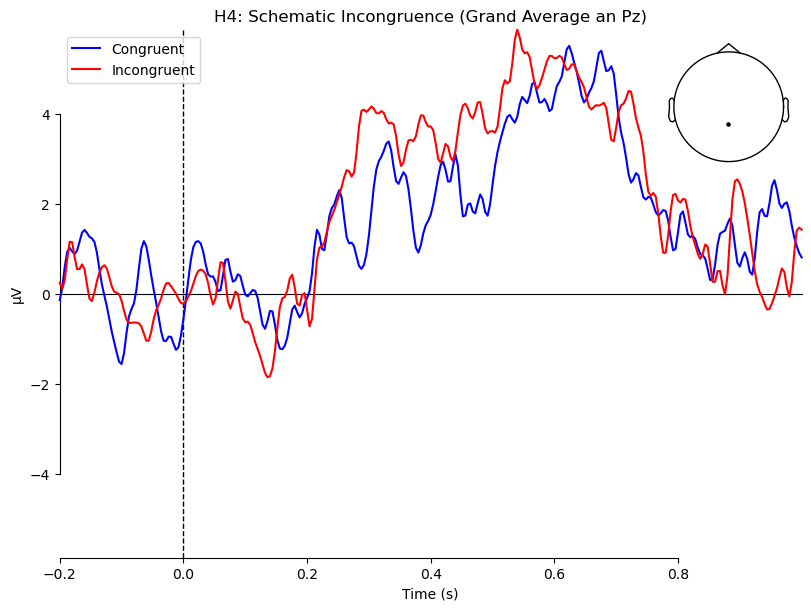

Identifying common channels ...
No projector specified for this dataset. Please consider the method self.add_proj.


C:\Users\noahm\AppData\Local\Temp\ipykernel_14680\3213671954.py:16: RuntimeWarning: Only a single dataset was passed to mne.grand_average().
  grand_diff_H4 = mne.grand_average(diff_H4_list)


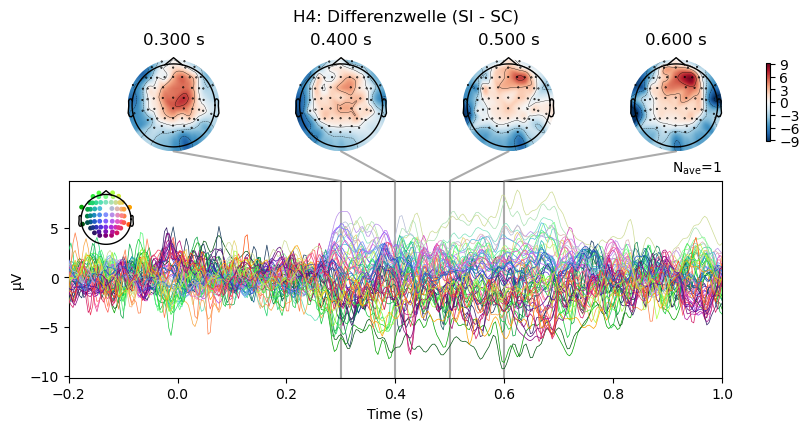

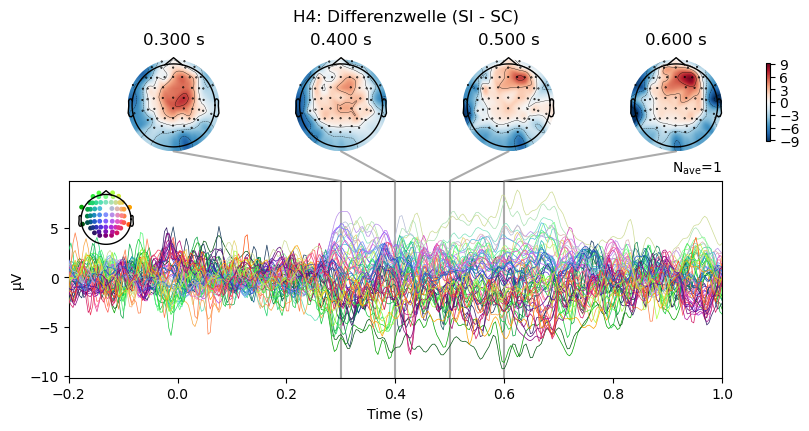

In [2]:
# Grand Averages berechnen
grand_SC = mne.grand_average(evokeds_SC)
grand_SI = mne.grand_average(evokeds_SI)

# Ein schöner MNE-Plot, der beide Bedingungen (SI vs SC) gegenüberstellt
# (Wir nehmen hier exemplarisch Elektrode Pz oder Cz, passe es an deine ROI an)
mne.viz.plot_compare_evokeds(
    dict(Congruent=grand_SC, Incongruent=grand_SI),
    picks=['Pz'],  # Oder eine Liste von Kanälen: ['P3', 'Pz', 'P4']
    colors=dict(Congruent='blue', Incongruent='red'),
    title="H4: Schematic Incongruence (Grand Average an Pz)",
    show_sensors=True
)

# Differenzwelle (Grand Average) als Topographie plotten
grand_diff_H4 = mne.grand_average(diff_H4_list)
grand_diff_H4.plot_joint(title="H4: Differenzwelle (SI - SC)", 
                         times=[0.3, 0.4, 0.5, 0.6]) # Zeige Topos an diesen Zeitpunkten

Zelle 3: Vorbereitung der Datenstruktur für den Permutation Test <br>
Der MNE Permutation-Test (spatio_temporal_cluster_1samp_test) ist sehr strikt, was die Datenform angeht. Er verlangt ein 3D-Numpy-Array in der Form: (Anzahl_Probanden, Anzahl_Zeitpunkte, Anzahl_Kanäle).
Zudem müssen wir ihm verraten, welche Elektroden räumlich nebeneinander liegen (Adjacency Matrix), damit er räumliche Cluster bilden kann.

In [3]:
# 1. Nachbarschafts-Matrix der Elektroden berechnen (Adjacency)
# MNE schaut in die Info deines Epochen-Objekts, um zu sehen, wo die Elektroden auf dem Kopf liegen
adjacency, ch_names = mne.channels.find_ch_adjacency(epochs.info, ch_type='eeg')

# 2. Funktion um Liste von Evokeds in das richtige 3D-Array zu verwandeln
def extract_data_for_stats(diff_list):
    # ev.data hat die Form (Kanäle, Zeiten). Wir müssen es transponieren zu (Zeiten, Kanäle)
    data = [np.transpose(ev.data, (1, 0)) for ev in diff_list]
    # np.array macht daraus (Probanden, Zeiten, Kanäle)
    return np.array(data)

# H4 Daten für die Statistik extrahieren
X_H4 = extract_data_for_stats(diff_H4_list)

print(f"Datenstruktur für H4 Statistik: {X_H4.shape}")
print(f"Erwartet: (Anzahl Probanden, Anzahl Zeitpunkte, Anzahl Kanäle)")

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
Datenstruktur für H4 Statistik: (1, 301, 63)
Erwartet: (Anzahl Probanden, Anzahl Zeitpunkte, Anzahl Kanäle)


Zelle 4: Cluster-based Permutation Test (Testen von H4) <br>
Jetzt wird es statistisch. Wir testen, wo die Differenzwelle signifikant von 0 abweicht. MNE berechnet erst t-Tests für jeden Datenpunkt, formt Cluster über Zeit und Raum, und vergleicht die Cluster-Größen dann mit 1000 zufällig permutierten Daten, um den p-Wert des Clusters zu bestimmen.

In [ ]:
from mne.stats import spatio_temporal_cluster_1samp_test

print("Starte Cluster Permutation Test für H4...")
# WICHTIG: Setze n_permutations zum Testen erstmal niedrig (z.B. 100), 
# da das sehr lange rechnet. Wenn der Code läuft, setze es für finale Ergebnisse auf 1000 oder 2000.

cluster_stats_H4 = spatio_temporal_cluster_1samp_test(
    X_H4,
    adjacency=adjacency,
    n_jobs=-1,              # Nutzt alle CPU-Kerne deines PCs
    n_permutations=1000,    # Anzahl der Permutationen
    tail=0,                 # 0 = Zweiseitiger Test (Abweichung in beide Richtungen erlaubt)
    verbose=True
)

# Die Funktion gibt verschiedene Dinge zurück:
T_obs, clusters, cluster_p_values, H0 = cluster_stats_H4

# Signifikante Cluster finden (p < 0.05)
good_cluster_inds = np.where(cluster_p_values < 0.05)[0]

if len(good_cluster_inds) > 0:
    print(f"\nJuhu! {len(good_cluster_inds)} signifikante(s) Cluster für H4 gefunden!")
    for i, ind in enumerate(good_cluster_inds):
        print(f"Cluster {i+1}: p-Wert = {cluster_p_values[ind]}")
else:
    print("\nLeider keine signifikanten Cluster für H4 gefunden (p > 0.05).")